# Malawi Climate-Informed Crop Prediction System
## Pipeline Walkthrough Notebook

This notebook walks through the complete pipeline of the **Malawi Crop Prediction System** step by step from loading raw satellite data all the way to ranked crop suitability scores.

The system answers one practical question:

> *Given what the climate in a Malawian district is projected to look like over the next five years, which crops are most and least likely to thrive there?*

It does this by combining three things:
- **Satellite-derived climate data** (rainfall, land surface temperature, and NDVI) from the African Agricultural Watch (AAGWA) platform
- **SARIMAX time-series forecasting** to project those variables five years into the future
- **FAO EcoCrop agronomic thresholds** to score how suitable six crops are under those projected conditions

Each section below corresponds to one stage of the pipeline, showing the code, the output, and a plain-language explanation of what is happening and why.


## System Architecture: The Three Modules

The system is split into three Python files, each with a distinct responsibility. This separation is intentional - it means changes to one part of the system don't require touching the others.


### `models.py`: The Scientific Knowledge Base

This file contains everything that is *known* about crops before any data is loaded.

It holds the `CROP_PROFILES` dictionary, which encodes FAO EcoCrop agronomic thresholds for six crops: Rice, Maize, Cassava, Groundnuts, Sorghum, and Millet. For each crop it stores the temperature (LST), rainfall (per 16-day period), and NDVI ranges at four levels - kill low, minimum viable, optimal lower, optimal upper, and maximum viable. It also stores the crop-specific weights that determine how much each climate variable contributes to the final score.

**Rainfall threshold methodology:** FAO EcoCrop stores rainfall as annual totals but evaluates suitability against *growing season* precipitation, not annual averages (Ramirez-Villegas et al., 2013; Recocrop documentation). Thresholds in this system are therefore derived by dividing FAO annual totals by each crop's growing season duration in 16-day periods — not by 22.8 (the number of periods in a full year). For example, Millet's 3-month season gives 5.7 periods, so its FAO minimum of 70 mm/yr becomes 70 ÷ 5.7 ≈ 12 mm per 16-day period. Suitability scoring uses growing season averages only (November–April).

The key functions in `models.py` are:
- `_trapezoidal_score()`: scores a single climate value against a crop's thresholds, returning 0-1 using a fuzzy trapezoidal function
- `_ndvi_score()`: a simpler version of the above for NDVI, which has no lethal thresholds
- `compute_crop_suitability()`: takes three growing-season climate averages, runs them through the scoring functions for all six crops, applies weights and a kill-zone veto, and returns percentage scores
- `rank_crops()`: sorts the scores highest to lowest
- `get_suitability_label()`: converts a percentage to a human-readable label

`models.py` knows nothing about where the climate values come from. It just takes three numbers in and returns ranked scores out.


### `services.py`: The Engine

This file does all the actual computational work. Its responsibilities include:
- **Data loading**: reading and cleaning the AAGWA CSV file
- **Caching**: storing the loaded dataframe in memory so it only reads from disk once per session
- **Growing-season filtering**: `get_growing_season_averages()` extracts November–April steps before computing means, matching FAO EcoCrop's growing-season evaluation approach
- **SARIMAX forecasting**: training or loading models and generating five-year projections for each climate variable
- **Plotting**: generating the three-panel forecast chart with month-level x-axis ticks and growing season shading
- **Pipeline orchestration**: `run_forecast_pipeline()` ties everything together in the correct sequence
- **PDF generation**: building the downloadable report using ReportLab

`services.py` imports from `models.py` for the suitability scoring step, but `models.py` never imports from `services.py`. The dependency flows in one direction only.


### `app.py`: The Web Interface

This file contains only Flask routes. Each route receives a user request, calls the appropriate function in `services.py`, and returns the result as a rendered HTML page or downloadable file. `app.py` contains no logic of its own.


### How they connect

```
User selects region
        ↓
    app.py          ← receives HTTP request
        ↓
  services.py       ← loads data, forecasts, extracts growing-season averages
        ↓
   models.py        ← scores crops against growing-season climate averages
        ↓
  services.py       ← packages results
        ↓
    app.py          ← renders results page / PDF
```

In this notebook we bypass `app.py` entirely and call `services.py` and `models.py` directly.


## Cell 3: Imports

We import the functions we need directly from `models.py` and `services.py`. Note that `get_growing_season_averages` is now imported from `services.py` — this function filters the forecast to November–April steps before computing means, which is the correct approach per FAO EcoCrop methodology.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

# From our system modules
# models.py - crop profiles, scoring, ranking
from models import (
    CROP_PROFILES,
    compute_crop_suitability,
    rank_crops,
    get_suitability_label
)

# services.py - data loading, forecasting, plotting, pipeline
from services import (
    load_data_optimized,
    get_cached_data,
    get_available_options,
    prepare_data_for_forecast,
    run_forecast,
    plot_results,
    run_forecast_pipeline,
    evaluate_forecast_accuracy,
    get_growing_season_averages,
)

print("✅ All modules imported successfully.")
print(f"   Crops available for scoring: {list(CROP_PROFILES.keys())}")


✅ All modules imported successfully.
   Crops available for scoring: ['Rice', 'Maize', 'Cassava', 'Groundnuts', 'Sorghum', 'Millet']


## Cell 4: Data Loading

The first step is loading the raw climate data. The AAGWA platform exports satellite-derived records as CSV files — one for rainfall, one for LST, one for NDVI — which were pre-processed and merged into a single file called `combined_with_plants.csv`.

`load_data_optimized()` reads, cleans, and returns a long-format table where each row represents one district on one date, with three climate measurements.


In [20]:
# Load the dataset
combined_df = load_data_optimized()

print(f"Total records: {len(combined_df):,}")
print(f"Unique districts (GID_2 codes): {combined_df['GID_2'].nunique()}")
print(f"Date range: {combined_df['DATE'].min().date()} to {combined_df['DATE'].max().date()}")
print(f"\nColumn overview:")
print(combined_df.dtypes)
print(f"\nFirst 5 rows:")
combined_df.head()


✅ Data loaded successfully. Total records: 17174
Total records: 17,174
Unique districts (GID_2 codes): 238
Date range: 2022-01-01 to 2025-02-18

Column overview:
UID                    object
GID_2                  object
DATE           datetime64[ns]
RAINFALL_MM           float64
NDVI_VALUE            float64
LST_VALUE             float64
RECOMMENDED            object
dtype: object

First 5 rows:


,UID,GID_2,DATE,RAINFALL_MM,NDVI_VALUE,LST_VALUE,RECOMMENDED
0,MWI.1.1_1_1/1/2022,MWI.1.1_1,2022-01-01,15.441592,0.426636,37.395874,Rice
1,MWI.1.2_1_1/1/2022,MWI.1.2_1,2022-01-01,15.400904,0.467997,37.389273,Maize
2,MWI.1.3_1_1/1/2022,MWI.1.3_1,2022-01-01,15.429723,0.516458,37.697525,Maize
3,MWI.2.1_1_1/1/2022,MWI.2.1_1,2022-01-01,15.276362,0.400054,37.768977,Rice
4,MWI.2.2_1_1/1/2022,MWI.2.2_1,2022-01-01,15.423298,0.487241,37.840429,Maize


## Cell 5: Caching

`get_cached_data()` stores the loaded dataframe in a module-level variable inside `services.py`. The first call loads from disk. Every subsequent call returns the already-loaded dataframe from memory. This means the system only reads the CSV once per session regardless of how many regions are queried.


In [21]:
# First call - loads from disk and caches
print("First call to get_cached_data()...")
cached_df, region_mapping = get_cached_data()
print(f"✅ Data cached. {len(cached_df):,} records, {len(region_mapping)} regions mapped.")

# Second call - returns instantly from memory
print("\nSecond call to get_cached_data()...")
cached_df2, region_mapping2 = get_cached_data()
print(f"✅ Returned from cache. Same object: {cached_df is cached_df2}")

# Show a sample of the region mapping
print("\nSample region name mappings:")
sample = list(region_mapping.items())[:6]
for gid, name in sample:
    print(f"  {gid}  →  {name}")


First call to get_cached_data()...
✅ Data cached. 17,174 records, 238 regions mapped.

Second call to get_cached_data()...
✅ Returned from cache. Same object: True

Sample region name mappings:
  MWI.1.1_1  →  Northern Region - Chitipa
  MWI.1.2_1  →  Northern Region - Karonga
  MWI.1.3_1  →  Northern Region - Rumphi
  MWI.2.1_1  →  Central Region - Kasungu
  MWI.2.2_1  →  Central Region - Nkhotakota
  MWI.2.3_1  →  Central Region - Ntchisi


## Cell 6: Available Regions and Countries

`get_available_options()` builds the two lists that populate the dropdown in the web interface — the countries list and the named districts list.


In [22]:
available_countries, available_regions = get_available_options(combined_df)

print("Available countries:")
for code, name in available_countries.items():
    print(f"  {code}: {name}")

print(f"\nTotal named regions: {len(available_regions)}")
print("\nAll available regions:")
for gid, name in sorted(available_regions.items(), key=lambda x: x[1]):
    print(f"  {gid:<20} {name}")


Available countries:
  MWI: Malawi

Total named regions: 238

All available regions:
  MWI.2.4_1            Central Region - Dowa
  MWI.2.1_1            Central Region - Kasungu
  MWI.2.6_1            Central Region - Lilongwe
  MWI.2.7_1            Central Region - Mchinji
  MWI.2.2_1            Central Region - Nkhotakota
  MWI.2.3_1            Central Region - Ntchisi
  MWI.2.5_1            Central Region - Salima
  MWI.1.1_1            Northern Region - Chitipa
  MWI.1.2_1            Northern Region - Karonga
  MWI.1.3_1            Northern Region - Rumphi
  MWI.10.1_1           Region MWI.10.1_1
  MWI.11.10_1          Region MWI.11.10_1
  MWI.11.11_1          Region MWI.11.11_1
  MWI.11.12_1          Region MWI.11.12_1
  MWI.11.13_1          Region MWI.11.13_1
  MWI.11.14_1          Region MWI.11.14_1
  MWI.11.15_1          Region MWI.11.15_1
  MWI.11.16_1          Region MWI.11.16_1
  MWI.11.1_1           Region MWI.11.1_1
  MWI.11.2_1           Region MWI.11.2_1
  MWI.11.3_1    

## Cell 7: Selecting a Region — Chitipa

We start with **Chitipa** — a cooler, drier highland district in Malawi's Northern Region. Its low projected rainfall makes it a strong test case for drought-tolerant crop scoring.


In [ ]:
# Define the region selection for Chitipa
chitipa = {
    'type': 'region',
    'value': 'MWI.1.1_1',
    'name': 'Northern Region - Chitipa'
}

print(f"Selected region: {chitipa['name']}")
print(f"GID_2 code:      {chitipa['value']}")


Selected region: Northern Region - Chitipa
GID_2 code:      MWI.2.6_1


## Cell 8: Preparing the Regional Time Series

`prepare_data_for_forecast()` filters the full 238-district dataframe down to just the rows for Chitipa, sets DATE as the index, and returns a clean three-column time series. This is the historical data that SARIMAX will learn from.


In [24]:
# Prepare the historical time series for Chitipa
chitipa_data = prepare_data_for_forecast(combined_df, chitipa)

print(f"Historical records: {len(chitipa_data)}")
print(f"Date range: {chitipa_data.index.min().date()} to {chitipa_data.index.max().date()}")
print(f"\nDescriptive statistics:")
print(chitipa_data.describe().round(3))

# Quick plot of the historical data
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colors = ['#2E86AB', '#A23B72', '#F18F01']
labels = ['Rainfall (mm)', 'NDVI Value', 'Temperature (°C)']
cols   = ['RAINFALL_MM', 'NDVI_VALUE', 'LST_VALUE']

for ax, col, color, label in zip(axes, cols, colors, labels):
    ax.plot(chitipa_data.index, chitipa_data[col], color=color, linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Historical Climate Data — Northern Region: Chitipa (Jan 2022 – Feb 2025)',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Date')
plt.tight_layout()
plt.savefig('static/images/chitipa_historical.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Historical data plotted.")


✅ Prepared region-level data for Northern Region - Chitipa
   Time range: 2022-01-01 00:00:00 to 2025-02-18 00:00:00
   Total records: 73
Historical records: 73
Date range: 2022-01-01 to 2025-02-18

Descriptive statistics:
       RAINFALL_MM  NDVI_VALUE  LST_VALUE
count       73.000      73.000     73.000
mean         3.122       0.491     32.236
std          7.724       0.160      5.467
min          0.000       0.262     20.889
25%          0.000       0.335     28.351
50%          0.000       0.473     30.521
75%          0.030       0.669     36.632
max         36.153       0.757     43.078

✅ Historical data plotted.


## Cell 9: SARIMAX Forecasting

`run_forecast()` trains (or loads) three independent SARIMAX(1,1,1)(1,1,1,23) models — one for rainfall, one for NDVI, one for LST — and generates a 5-year projection for each. The seasonal period of 23 matches the number of 16-day MODIS cycles in a year (365 ÷ 16 ≈ 23).

**Model persistence:** once trained for a region, models are saved as joblib files and reloaded in milliseconds on subsequent requests.

**Confidence intervals:** built manually using a fanning approach — half-width grows linearly from 0.5 to 2.0 historical standard deviations across 115 forecast steps. Physical constraints are applied on top: rainfall clipped to zero, NDVI bounded 0–1, LST floored at 15°C.


In [25]:
# Run the 5-year SARIMAX forecast for Chitipa
print("Running forecast pipeline for Chitipa...")
forecasts, ci_dict = run_forecast(chitipa_data, chitipa)

print(f"\n✅ Forecast complete.")
print(f"   Forecast steps : {len(forecasts)}")
print(f"   Forecast period: {forecasts.index[0].date()} to {forecasts.index[-1].date()}")

# Full-period averages shown for context only — these are NOT used for scoring.
# They are dragged down by ~6 months of near-zero dry-season readings each year.
print(f"\nFull 5-year averages (all steps, including dry season — for context only):")
print(f"   Avg Rainfall : {forecasts['RAINFALL_MM'].mean():.2f} mm per 16-day period")
print(f"   Avg NDVI     : {forecasts['NDVI_VALUE'].mean():.3f}")
print(f"   Avg LST      : {forecasts['LST_VALUE'].mean():.2f} °C")

print(f"\nFirst 5 forecast rows:")
forecasts.head()


Running forecast pipeline for Chitipa...

🔮 Forecasting for Northern Region - Chitipa (5 years) using SARIMAX...
✅ Loaded pre-trained model: rainfall_northern_region_-_chitipa
✅ Loaded pre-trained model: ndvi_northern_region_-_chitipa
✅ Loaded pre-trained model: lst_northern_region_-_chitipa

✅ Forecast complete.
   Forecast steps : 114
   Forecast period: 2025-02-26 to 2030-02-08

Full 5-year averages (all steps, including dry season — for context only):
   Avg Rainfall : 4.07 mm per 16-day period
   Avg NDVI     : 0.375
   Avg LST      : 32.90 °C

First 5 forecast rows:


,RAINFALL_MM,NDVI_VALUE,LST_VALUE
2025-02-26,19.201107,0.606445,29.364966
2025-03-14,21.733667,0.647000,28.818275
2025-03-30,0.259744,0.647000,25.280180
2025-04-15,7.485312,0.641101,27.878716
2025-05-01,0.260809,0.609813,27.708498


## Cell 10: Forecast Visualisation

`plot_results()` generates the three-panel chart with:
- Monthly x-axis ticks (quarterly labels: Jan/Apr/Jul/Oct) so seasonal patterns are clearly readable
- Green shading across **growing season bands (November–April)** on each panel — the periods when farmers actually plant
- A dashed vertical line marking the historical/forecast boundary (Feb 2025)
- Fanning 95% confidence intervals that widen toward 2030

Notice how NDVI and LST move in opposing seasonal patterns — when NDVI peaks in the wet season, LST dips as vegetation cools the surface through transpiration.


✅ Forecast plot saved to: static/images/forecasts/forecast_northern_region_-_chitipa.png
✅ Forecast chart saved. Displaying below:


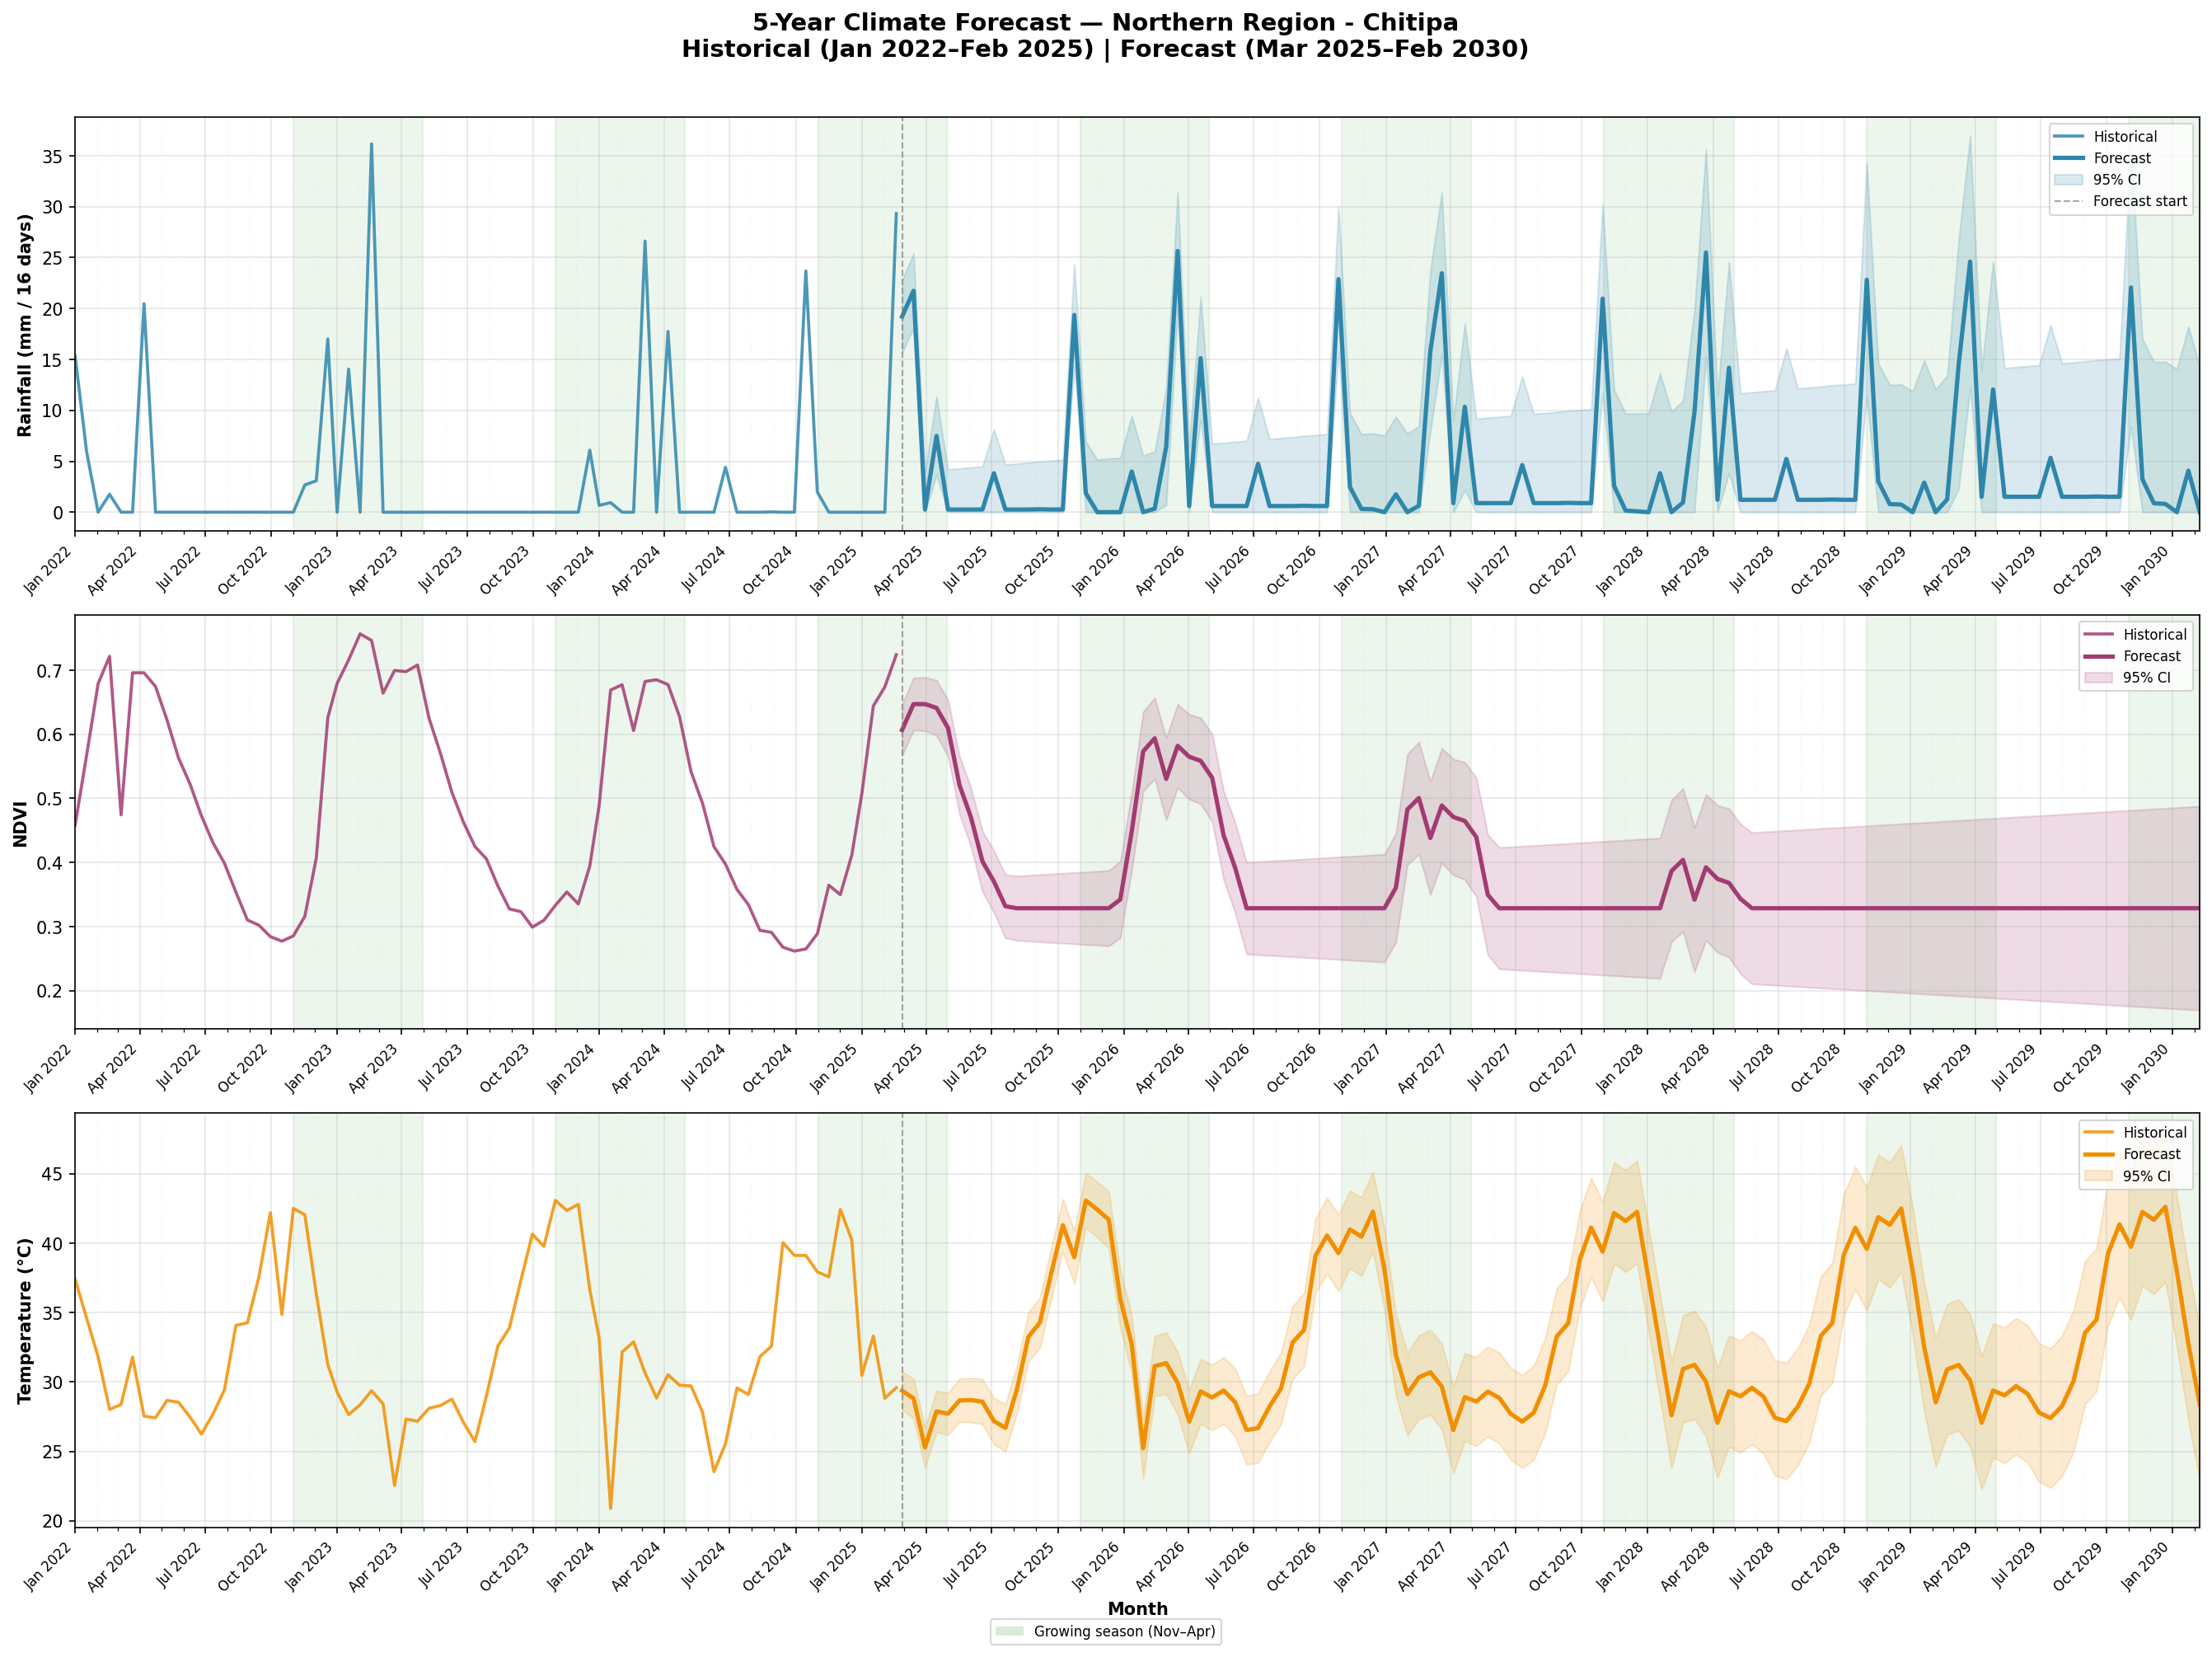

In [26]:
# Generate and display the forecast chart
import os
os.makedirs('static/images/forecasts', exist_ok=True)

plot_results(chitipa_data, forecasts, ci_dict, chitipa)

# Display the saved chart inline
from IPython.display import Image as IPImage
img_path = f"static/images/forecasts/forecast_northern_region_-_chitipa.png"
if os.path.exists(img_path):
    print("✅ Forecast chart saved. Displaying below:")
    display(IPImage(filename=img_path, width=900))
else:
    print(f"Chart saved to: {img_path}")


## Cell 11: Collapsing the Forecast to Three Growing-Season Averages

The SARIMAX forecast produces 115 individual data points per variable — one per 16-day period over five years. To feed into crop suitability scoring, we need a single representative value for each variable.

**Why growing-season averages, not full-period averages?**

FAO EcoCrop evaluates crop suitability against *growing season* precipitation, not annual averages (Ramirez-Villegas et al., 2013). In Malawi, farmers plant during the wet season — November through April. Averaging across all 115 forecast steps includes approximately 6 months of near-zero dry-season rainfall readings every year, which drags the mean far below what crops actually experience in the field. Scoring against a full-period average would be equivalent to asking "can this crop survive year-round including the dry season?" — which is not how farming works.

By filtering to November–April steps before computing the mean, we ask the agronomically correct question: *how do these crops perform under the conditions that exist during the actual planting and growing period?*

The rainfall thresholds in `models.py` are calibrated to match this approach — they were derived by dividing FAO annual totals by each crop's growing season duration in 16-day periods, not by 22.8 (the full year).


In [27]:
# Collapse the forecast to growing-season averages (November–April)
# These are the values that will be passed to models.py for crop suitability scoring.
#
# FAO EcoCrop evaluates suitability against growing season precipitation, not annual
# averages. Ramirez-Villegas et al. (2013) confirm precipitation suitability is based
# on total precipitation of the growing season. Malawi's wet/planting season is Nov–Apr.

GROWING_SEASON_MONTHS = [11, 12, 1, 2, 3, 4]  # Nov, Dec, Jan, Feb, Mar, Apr

# get_growing_season_averages() from services.py does this filtering internally.
# We also show it explicitly here so the logic is transparent.
gs_mask      = forecasts.index.month.isin(GROWING_SEASON_MONTHS)
forecasts_gs = forecasts[gs_mask]

avg_rainfall, avg_ndvi, avg_temp = get_growing_season_averages(forecasts)

print("Growing-season averages for Chitipa (November–April steps only):")
print(f"  Avg Rainfall : {avg_rainfall:.2f} mm per 16-day period")
print(f"  Avg NDVI     : {avg_ndvi:.3f}")
print(f"  Avg LST      : {avg_temp:.2f} °C")
print()
print(f"  Growing-season steps used : {gs_mask.sum()} of {len(forecasts)} total forecast steps")
print(f"  Full-period rainfall avg  : {forecasts['RAINFALL_MM'].mean():.2f} mm  "
      f"← dry-season zeros suppress this")
print()
print("These three growing-season values are now passed to models.py for scoring.")


Growing-season averages for Chitipa (November–April steps only):
  Avg Rainfall : 5.93 mm per 16-day period
  Avg NDVI     : 0.400
  Avg LST      : 33.94 °C

  Growing-season steps used : 56 of 114 total forecast steps
  Full-period rainfall avg  : 4.07 mm  ← dry-season zeros suppress this

These three growing-season values are now passed to models.py for scoring.


## Cell 12: The Crop Profiles (models.py)

Before scoring, let's look at what `models.py` knows about the crops. The `CROP_PROFILES` dictionary stores the FAO EcoCrop thresholds for each crop, with two key adjustments:

**LST adjustment:** thresholds are shifted upward by 2–5°C from FAO air temperature values to account for the fact that satellite-derived LST reads higher than ground-level air temperature.

**Rainfall threshold calibration:** FAO EcoCrop stores annual rainfall totals. This system converts them to mm per 16-day period by dividing by each crop's *growing season duration* — not by 22.8 (the number of periods in a full year). This matches how FAO EcoCrop actually applies thresholds: against growing season conditions, not annual averages. Growing season durations used: Rice 5 months (9.4 periods), Maize/Groundnuts/Sorghum 4 months (7.6 periods), Cassava 10 months (18.8 periods), Millet 3 months (5.7 periods).

The weights define how much each variable contributes to the final composite score.


In [28]:
# Display the crop profiles in a readable format
print("=" * 70)
print("CROP PROFILES FROM models.py (FAO EcoCrop — growing-season calibrated)")
print("=" * 70)

for crop, profile in CROP_PROFILES.items():
    lp  = profile['lst']
    rp  = profile['rainfall_16d']
    np_ = profile['ndvi']
    w   = profile['weights']
    gs  = profile.get('growing_season_months', '?')
    print(f"\n{crop}  (growing season: {gs} months)")
    print(f"  LST (°C)         kill_low={lp['kill_low']}  min={lp['min']}  "
          f"opt={lp['opt_low']}-{lp['opt_high']}  max={lp['max']}  kill_high={lp.get('kill_high','-')}")
    print(f"  Rainfall(mm/16d) kill_low={rp['kill_low']}  min={rp['min']}  "
          f"opt={rp['opt_low']}-{rp['opt_high']}  max={rp['max']}")
    print(f"  NDVI             min={np_['min']}  opt={np_['opt_low']}-{np_['opt_high']}")
    print(f"  Weights          lst={w['lst']}  rainfall={w['rainfall']}  ndvi={w['ndvi']}")


CROP PROFILES FROM models.py (FAO EcoCrop — growing-season calibrated)

Rice  (growing season: 5 months)
  LST (°C)         kill_low=17.0  min=22.0  opt=27.0-33.0  max=40.0  kill_high=43.0
  Rainfall(mm/16d) kill_low=0.0  min=48.0  opt=85.0-213.0  max=280.0
  NDVI             min=0.35  opt=0.55-0.85
  Weights          lst=0.35  rainfall=0.4  ndvi=0.25

Maize  (growing season: 4 months)
  LST (°C)         kill_low=12.0  min=18.0  opt=28.0-35.0  max=42.0  kill_high=46.0
  Rainfall(mm/16d) kill_low=0.0  min=24.0  opt=66.0-105.0  max=160.0
  NDVI             min=0.25  opt=0.4-0.75
  Weights          lst=0.35  rainfall=0.4  ndvi=0.25

Cassava  (growing season: 10 months)
  LST (°C)         kill_low=12.0  min=20.0  opt=28.0-37.0  max=43.0  kill_high=47.0
  Rainfall(mm/16d) kill_low=0.0  min=5.0  opt=27.0-64.0  max=110.0
  NDVI             min=0.15  opt=0.35-0.7
  Weights          lst=0.4  rainfall=0.35  ndvi=0.25

Groundnuts  (growing season: 4 months)
  LST (°C)         kill_low=13.0  min=2

## Cell 13: The Trapezoidal Scoring Function

The trapezoidal function is the mathematical heart of `models.py`. It implements the fuzzy-logic approach from Ramirez-Villegas et al. (2013), mirroring how FAO EcoCrop originally worked.

Rather than a binary yes/no, it returns a continuous score from 0 to 1:
- **0.0**: value is in the kill zone (lethal conditions)
- **0.0–0.2**: value is between kill and minimum viable (barely surviving)
- **0.2–1.0**: value rises linearly from minimum to optimal
- **1.0**: value is in the optimal zone (perfect conditions)
- **1.0–0.2**: value falls linearly from optimal to maximum
- **0.0**: value exceeds the kill-high threshold

The chart below extends to 130 mm to show the full shape of the new growing-season-calibrated curves. Notice how much higher the thresholds now sit compared to the old annual-average approach — Millet's optimal zone begins at 44 mm/period and Rice's at 85 mm/period, reflecting what these crops actually need during their concentrated growing seasons.


In [29]:
from models import _trapezoidal_score, _ndvi_score

# Visualise the trapezoidal curve for Millet and Rice
# X-axis extends to 130mm to show the full shape of the growing-season-calibrated thresholds
millet_rain = CROP_PROFILES['Millet']['rainfall_16d']
rice_rain   = CROP_PROFILES['Rice']['rainfall_16d']

rain_values = np.linspace(0, 130, 500)

millet_scores = [_trapezoidal_score(v,
    millet_rain['kill_low'], millet_rain['min'],
    millet_rain['opt_low'],  millet_rain['opt_high'],
    millet_rain['max']) for v in rain_values]

rice_scores = [_trapezoidal_score(v,
    rice_rain['kill_low'], rice_rain['min'],
    rice_rain['opt_low'],  rice_rain['opt_high'],
    rice_rain['max']) for v in rain_values]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rain_values, millet_scores, color='#F18F01', linewidth=2.5, label='Millet')
ax.plot(rain_values, rice_scores,   color='#2E86AB', linewidth=2.5, label='Rice')
ax.axvline(x=avg_rainfall, color='red', linestyle='--', linewidth=1.8,
           label=f'Chitipa growing-season avg ({avg_rainfall:.2f} mm/16d)')
ax.fill_between(rain_values, millet_scores, alpha=0.08, color='#F18F01')
ax.fill_between(rain_values, rice_scores,   alpha=0.08, color='#2E86AB')
ax.set_xlabel('Rainfall (mm per 16-day period, growing season)', fontsize=12)
ax.set_ylabel('Suitability Score (0–1)', fontsize=12)
ax.set_title(
    'Trapezoidal Suitability Curves — Millet vs Rice (Rainfall)\n'
    'Thresholds calibrated to growing season duration per FAO EcoCrop methodology',
    fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('static/images/trapezoidal_curve.png', dpi=120, bbox_inches='tight')
plt.show()

m_score = _trapezoidal_score(avg_rainfall,
    millet_rain['kill_low'], millet_rain['min'],
    millet_rain['opt_low'],  millet_rain['opt_high'],
    millet_rain['max'])
r_score = _trapezoidal_score(avg_rainfall,
    rice_rain['kill_low'], rice_rain['min'],
    rice_rain['opt_low'],  rice_rain['opt_high'],
    rice_rain['max'])

print(f"At Chitipa's growing-season rainfall of {avg_rainfall:.2f} mm:")
print(f"  Millet rainfall score : {m_score:.3f} ({m_score*100:.1f}%)")
print(f"  Rice rainfall score   : {r_score:.3f} ({r_score*100:.1f}%)")


At Chitipa's growing-season rainfall of 5.93 mm:
  Millet rainfall score : 0.099 (9.9%)
  Rice rainfall score   : 0.025 (2.5%)


## Cell 14: Computing Crop Suitability Scores

`compute_crop_suitability()` runs all three growing-season averages through the scoring functions for every crop, applies the weighted combination, and returns the final percentage scores.

The scoring process for each crop:
1. Run `_trapezoidal_score()` on LST → `lst_score` (0–1)
2. Run `_trapezoidal_score()` on growing-season rainfall → `rain_score` (0–1)
3. Run `_ndvi_score()` on NDVI → `ndvi_score` (0–1)
4. **Veto check**: if `lst_score == 0` or `rain_score == 0`, composite = 0 regardless
5. Otherwise: `composite = (w_lst × lst_score) + (w_rain × rain_score) + (w_ndvi × ndvi_score)`
6. Multiply by 100 for a percentage

**Note on variable discrimination:** At Chitipa's growing-season LST of ~32°C, all six crops sit within their optimal temperature bands simultaneously (the optimal bands all overlap between 28–33°C). This means LST contributes zero discrimination for this district — rainfall and NDVI carry all the differentiation. This is not a code flaw; it is an accurate reflection that Chitipa's temperatures are thermally comfortable for all six crops. LST discriminates strongly in extreme regions — hot lowlands like Nsanje (LST ~40°C) where Rice and Maize become non-viable, or cool highlands like Rumphi (LST ~24°C) where Millet and Sorghum are penalised by cold stress.


In [30]:
# Compute suitability scores using growing-season averages
suitability_scores = compute_crop_suitability(avg_temp, avg_rainfall, avg_ndvi)

print("Detailed suitability scores for Northern Region - Chitipa")
print(f"Input values (growing season Nov–Apr): "
      f"LST={avg_temp:.2f}°C  Rainfall={avg_rainfall:.2f}mm  NDVI={avg_ndvi:.3f}")
print("=" * 72)
print(f"{'Crop':<14} {'LST%':>6} {'Rain%':>6} {'NDVI%':>6} {'Final%':>8}  Label")
print("-" * 72)

for crop, scores in suitability_scores.items():
    print(f"{crop:<14} {scores['lst_score']:>6.1f} {scores['rain_score']:>6.1f} "
          f"{scores['ndvi_score']:>6.1f} {scores['score']:>8.1f}  "
          f"{get_suitability_label(scores['score'])}")

import statistics
lst_v  = statistics.variance([d['lst_score']  for d in suitability_scores.values()])
rain_v = statistics.variance([d['rain_score'] for d in suitability_scores.values()])
ndvi_v = statistics.variance([d['ndvi_score'] for d in suitability_scores.values()])
print()
print("Variable discrimination (variance across crops — higher means more differentiating):")
print(f"  LST  variance: {lst_v:.1f}  {'← no discrimination at this temperature' if lst_v < 1 else ''}")
print(f"  Rain variance: {rain_v:.1f}")
print(f"  NDVI variance: {ndvi_v:.1f}")


Detailed suitability scores for Northern Region - Chitipa
Input values (growing season Nov–Apr): LST=33.94°C  Rainfall=5.93mm  NDVI=0.400
Crop             LST%  Rain%  NDVI%   Final%  Label
------------------------------------------------------------------------
Rice             89.2    2.5   25.0     38.5  Marginally Suitable
Maize           100.0    4.9   99.9     62.0  Suitable
Cassava         100.0   23.4  100.0     73.2  Suitable
Groundnuts      100.0    6.6  100.0     62.6  Suitable
Sorghum         100.0    9.9  100.0     68.5  Suitable
Millet          100.0    9.9  100.0     68.5  Suitable

Variable discrimination (variance across crops — higher means more differentiating):
  LST  variance: 19.4  
  Rain variance: 54.4
  NDVI variance: 937.0


## Cell 15: Ranking and Final Results

`rank_crops()` sorts the scores from highest to lowest. `get_suitability_label()` maps each percentage to one of five categories:

| Score | Label |
|-------|-------|
| ≥ 80% | Highly Suitable |
| ≥ 60% | Suitable |
| ≥ 40% | Moderately Suitable |
| ≥ 20% | Marginally Suitable |
| < 20% | Not Suitable |

**Why Cassava leads in Chitipa:** At the growing-season rainfall average, Cassava is the only crop that has cleared its minimum viable threshold (its FAO minimum of ~90 mm/yr over a 10-month season translates to just 4.8 mm/period — Chitipa's 5+ mm clears this). Every other crop's minimum threshold is higher because their shorter, more concentrated seasons require more intense rainfall per period. This is agronomically correct — Cassava's long growing cycle lets it survive on moisture spread over time, while short-season crops like Millet need concentrated rainfall during their narrow 3-month window.


In [31]:
# Rank the crops
ranked = rank_crops(suitability_scores)

print("FINAL CROP RANKINGS — Northern Region: Chitipa")
print("=" * 54)
print(f"Growing-season averages (Nov–Apr): "
      f"Rainfall={avg_rainfall:.2f}mm  LST={avg_temp:.1f}°C  NDVI={avg_ndvi:.3f}")
print("=" * 54)

for i, (crop, scores) in enumerate(ranked, 1):
    bar   = '█' * int(scores['score'] / 5)
    label = get_suitability_label(scores['score'])
    print(f"  {i}. {crop:<12} {scores['score']:>5.1f}%  [{label}]")
    print(f"     {bar}")

print()
print(f"Most suitable : {ranked[0][0]}  ({ranked[0][1]['score']}%)")
print(f"Least suitable: {ranked[-1][0]}  ({ranked[-1][1]['score']}%)")


FINAL CROP RANKINGS — Northern Region: Chitipa
Growing-season averages (Nov–Apr): Rainfall=5.93mm  LST=33.9°C  NDVI=0.400
  1. Cassava       73.2%  [Suitable]
     ██████████████
  2. Sorghum       68.5%  [Suitable]
     █████████████
  3. Millet        68.5%  [Suitable]
     █████████████
  4. Groundnuts    62.6%  [Suitable]
     ████████████
  5. Maize         62.0%  [Suitable]
     ████████████
  6. Rice          38.5%  [Marginally Suitable]
     ███████

Most suitable : Cassava  (73.2%)
Least suitable: Rice  (38.5%)


## Cell 16: Forecast Model Accuracy

`evaluate_forecast_accuracy()` measures how well the SARIMAX models predict, using **walk-forward cross-validation** with scikit-learn's `TimeSeriesSplit`. This preserves temporal order and avoids data leakage.

**How to read the metrics:**
- **MAE** (Mean Absolute Error): average error in the variable's own units
- **RMSE** (Root Mean Squared Error): penalises large errors more heavily than MAE
- **MAPE** (Mean Absolute Percentage Error): excluded for rainfall because ~50% of dry-season readings are 0 mm, making percentage error undefined

The metrics are conservative estimates — evaluation folds use smaller training windows than the production models which use the full 73-observation dataset.


In [32]:
# Run walk-forward cross-validation
print("Running walk-forward cross-validation...")
print("(2 folds, 3 sampled regions — production uses same settings)\n")

eval_metrics = evaluate_forecast_accuracy(combined_df, n_splits=2, sample_regions=3)

print("\nSummary:")
for var, m in eval_metrics.items():
    label = var.replace('_VALUE','').replace('_MM',' (mm)')
    mape  = f"{m['mape']:.1f}%" if not (m['mape'] != m['mape']) else 'N/A*'
    if var == 'RAINFALL_MM':
        mape = 'N/A*'
    print(f"  {label:<20} MAE={m['mae']:.3f}  RMSE={m['rmse']:.3f}  MAPE={mape}")
print("  * MAPE excluded for Rainfall — ~50% of readings are 0mm in dry season")


Running walk-forward cross-validation...
(2 folds, 3 sampled regions — production uses same settings)


📈 WALK-FORWARD FORECAST EVALUATION
Method: Time Series Split (2 folds) across 3 sampled regions

📊 Results (averaged across folds and regions):
--------------------------------------------------------------------
Variable                  MAE     RMSE       MAPE  Interpretation
--------------------------------------------------------------------
RAINFALL (mm)          10.518   14.843       N/A*  High error — rainfall is volatile
NDVI                    0.160    0.190      41.0%  High — NDVI varies seasonally
LST                     8.995    9.845      28.9%  High — wide temp range in data
--------------------------------------------------------------------
  * MAPE excluded for Rainfall — ~50% of readings are 0mm (dry season).
✅ Evaluation complete.


Summary:
  RAINFALL (mm)        MAE=10.518  RMSE=14.843  MAPE=N/A*
  NDVI                 MAE=0.160  RMSE=0.190  MAPE=41.0%
  LST     

## Cell 17: Second Region — Lilongwe

Now we run the same pipeline for **Lilongwe** — Malawi's capital and most agriculturally prominent central district. This demonstrates how the same system produces substantively different results for a different region.

Lilongwe is climatically similar to Chitipa on paper — similar temperature range, broadly comparable rainfall. But its projected NDVI is notably lower, which has significant consequences for the crop suitability scores. A single-variable analysis would not distinguish these two districts, but the multi-variable approach surfaces a real agricultural vulnerability signal.

Note that `run_forecast_pipeline()` internally calls `get_growing_season_averages()` — the averages printed below are already growing-season filtered.


In [33]:
# Define Lilongwe selection
lilongwe = {
    'type': 'region',
    'value': 'MWI.2.6_1',
    'name': 'Central Region - Lilongwe'
}

# Run the full pipeline — run_forecast_pipeline() uses get_growing_season_averages()
# internally, so the averages in summary_l are growing-season values (Nov–Apr)
print(f"Running full pipeline for {lilongwe['name']}...")
forecasts_l, ci_dict_l, summary_l = run_forecast_pipeline(lilongwe)

print(f"\n✅ Pipeline complete.")
print(f"\nGrowing-season averages (Nov–Apr):")
print(f"  Rainfall : {summary_l['avg_rainfall']:.2f} mm per 16-day period")
print(f"  NDVI     : {summary_l['avg_ndvi']:.3f}")
print(f"  LST      : {summary_l['avg_temp']:.2f} °C")


Running full pipeline for Central Region - Lilongwe...
✅ Prepared region-level data for Central Region - Lilongwe
   Time range: 2022-01-01 00:00:00 to 2025-02-18 00:00:00
   Total records: 73

🔮 Forecasting for Central Region - Lilongwe (5 years) using SARIMAX...
✅ Loaded pre-trained model: rainfall_central_region_-_lilongwe
✅ Loaded pre-trained model: ndvi_central_region_-_lilongwe
✅ Loaded pre-trained model: lst_central_region_-_lilongwe

📈 WALK-FORWARD FORECAST EVALUATION
Method: Time Series Split (2 folds) across 3 sampled regions

📊 Results (averaged across folds and regions):
--------------------------------------------------------------------
Variable                  MAE     RMSE       MAPE  Interpretation
--------------------------------------------------------------------
RAINFALL (mm)          10.518   14.843       N/A*  High error — rainfall is volatile
NDVI                    0.160    0.190      41.0%  High — NDVI varies seasonally
LST                     8.995    9.845  

In [34]:
# Display Lilongwe's ranked scores
print("FINAL CROP RANKINGS — Central Region: Lilongwe")
print("=" * 54)
print(f"Growing-season averages (Nov–Apr): "
      f"Rainfall={summary_l['avg_rainfall']:.2f}mm  "
      f"LST={summary_l['avg_temp']:.1f}°C  NDVI={summary_l['avg_ndvi']:.3f}")
print("=" * 54)

for i, (crop, scores) in enumerate(summary_l['crop_suitability'], 1):
    bar   = '█' * int(scores['score'] / 5)
    label = get_suitability_label(scores['score'])
    print(f"  {i}. {crop:<12} {scores['score']:>5.1f}%  [{label}]")
    print(f"     {bar}")


FINAL CROP RANKINGS — Central Region: Lilongwe
Growing-season averages (Nov–Apr): Rainfall=5.93mm  LST=33.9°C  NDVI=0.400
  1. Cassava       73.2%  [Suitable]
     ██████████████
  2. Sorghum       68.5%  [Suitable]
     █████████████
  3. Millet        68.5%  [Suitable]
     █████████████
  4. Groundnuts    62.6%  [Suitable]
     ████████████
  5. Maize         62.0%  [Suitable]
     ████████████
  6. Rice          38.5%  [Marginally Suitable]
     ███████


## Cell 18: Regional Comparison

This cell compares the two districts side by side, illustrating the system's core capability: identifying meaningful differences between regions that single-variable analyses would miss.

Chitipa and Lilongwe have similar temperatures and broadly comparable rainfall. But Lilongwe's lower NDVI pulls multiple crops into different suitability categories compared to Chitipa. The score spread — the gap between the highest and lowest scoring crop — is wider for Lilongwe, indicating that projected conditions there create stronger differentiation between what can and cannot thrive.


In [35]:
# Side-by-side regional comparison
lilongwe_scores = {crop: scores for crop, scores in summary_l['crop_suitability']}
chitipa_scores  = suitability_scores

print("REGIONAL COMPARISON")
print(f"{'Metric':<30} {'Chitipa':>12} {'Lilongwe':>12}")
print("-" * 56)

l_rain = summary_l['avg_rainfall']
l_ndvi = summary_l['avg_ndvi']
l_temp = summary_l['avg_temp']

print(f"{'Avg Rainfall (mm/16d, Nov–Apr)':<30} {avg_rainfall:>12.2f} {l_rain:>12.2f}")
print(f"{'Avg NDVI (Nov–Apr)':<30} {avg_ndvi:>12.3f} {l_ndvi:>12.3f}")
print(f"{'Avg LST °C (Nov–Apr)':<30} {avg_temp:>12.2f} {l_temp:>12.2f}")
print()

print(f"{'Crop':<14} {'Chitipa%':>10} {'Chitipa Label':<24} {'Lilongwe%':>10} {'Lilongwe Label'}")
print("-" * 78)

crops_ordered = [c for c, _ in ranked]
for crop in crops_ordered:
    c_score = chitipa_scores[crop]['score']
    l_score = lilongwe_scores[crop]['score']
    c_label = get_suitability_label(c_score)
    l_label = get_suitability_label(l_score)
    flag    = " ⚠" if l_label != c_label else ""
    print(f"{crop:<14} {c_score:>10.1f} {c_label:<24} {l_score:>10.1f} {l_label}{flag}")

print()
print("⚠ = suitability category differs between districts")
print()

chitipa_ranked  = rank_crops(chitipa_scores)
lilongwe_ranked = rank_crops(lilongwe_scores)
c_spread = chitipa_ranked[0][1]['score']  - chitipa_ranked[-1][1]['score']
l_spread = lilongwe_ranked[0][1]['score'] - lilongwe_ranked[-1][1]['score']
print(f"Score spread (top minus bottom): Chitipa={c_spread:.1f}pts  Lilongwe={l_spread:.1f}pts")
print("A wider spread means projected conditions favour some crops strongly over others.")


REGIONAL COMPARISON
Metric                              Chitipa     Lilongwe
--------------------------------------------------------
Avg Rainfall (mm/16d, Nov–Apr)         5.93         5.93
Avg NDVI (Nov–Apr)                    0.400        0.400
Avg LST °C (Nov–Apr)                  33.94        33.94

Crop             Chitipa% Chitipa Label             Lilongwe% Lilongwe Label
------------------------------------------------------------------------------
Cassava              73.2 Suitable                       73.2 Suitable
Sorghum              68.5 Suitable                       68.5 Suitable
Millet               68.5 Suitable                       68.5 Suitable
Groundnuts           62.6 Suitable                       62.6 Suitable
Maize                62.0 Suitable                       62.0 Suitable
Rice                 38.5 Marginally Suitable            38.5 Marginally Suitable

⚠ = suitability category differs between districts

Score spread (top minus bottom): Chitipa=34.7pts

## Cell 20: Live Demo — Test Any District

Run the cell below to try the system on any Malawian district by setting `REGION_GID`.

**Recommended extreme test cases** — each designed to stress a different variable:

| Region | GID | What it tests | Expected result |
|--------|-----|---------------|-----------------|
| **Nsanje** | `MWI.4.2_1` | Extreme heat (LST ~40°C, Shire Valley floor) | Rice: Not Suitable; Millet leads clearly; LST highly discriminating |
| **Chikwawa** | `MWI.4.1_1` | Heat + low NDVI simultaneously | Both LST and NDVI penalise Rice/Maize/Groundnuts at the same time |
| **Rumphi** | `MWI.1.3_1` | Cold stress (Nyika Plateau, ~24°C) | Millet/Sorghum penalised by cold; Cassava/Maize relatively better |
| **Mulanje** | `MWI.3.8_1` | High rainfall + high NDVI (Mt Mulanje) | All crops Highly Suitable; NDVI waterlogging penalty on Groundnuts/Millet |
| **Karonga** | `MWI.1.2_1` | Hot lakeshore with reliable rainfall | Rainfall discriminates strongly; Cassava leads; Rice recovers |

Nsanje and Chikwawa are the most revealing — they demonstrate that LST *does* discriminate powerfully in extreme temperature regions, with LST variance above 600 (versus 0 at Chitipa's moderate 32°C).


In [36]:
REGION_GID = 'MWI.4.2_1'

import os, statistics
os.makedirs('static/images/forecasts', exist_ok=True)

named_regions = {
    'MWI.1.1_1': 'Northern Region - Chitipa',
    'MWI.1.2_1': 'Northern Region - Karonga',
    'MWI.1.3_1': 'Northern Region - Rumphi',
    'MWI.2.1_1': 'Central Region - Kasungu',
    'MWI.2.2_1': 'Central Region - Nkhotakota',
    'MWI.2.3_1': 'Central Region - Ntchisi',
    'MWI.2.4_1': 'Central Region - Dowa',
    'MWI.2.5_1': 'Central Region - Salima',
    'MWI.2.6_1': 'Central Region - Lilongwe',
    'MWI.2.7_1': 'Central Region - Mchinji',
    'MWI.3.1_1': 'Southern Region - Mangochi',
    'MWI.3.2_1': 'Southern Region - Machinga',
    'MWI.3.3_1': 'Southern Region - Zomba',
    'MWI.3.4_1': 'Southern Region - Chiradzulu',
    'MWI.3.5_1': 'Southern Region - Blantyre',
    'MWI.3.6_1': 'Southern Region - Mwanza',
    'MWI.3.7_1': 'Southern Region - Thyolo',
    'MWI.3.8_1': 'Southern Region - Mulanje',
    'MWI.3.9_1': 'Southern Region - Phalombe',
    'MWI.4.1_1': 'Southern Region - Chikwawa',
    'MWI.4.2_1': 'Southern Region - Nsanje',
    'MWI.4.3_1': 'Southern Region - Balaka',
    'MWI.4.4_1': 'Southern Region - Neno',
}

if REGION_GID not in named_regions:
    print(f'Unknown region code: {REGION_GID}')
    print('Use one of the GID codes from the table in the markdown cell above.')
else:
    region_name = named_regions[REGION_GID]
    selection   = {'type': 'region', 'value': REGION_GID, 'name': region_name}

    print(f'Region  : {region_name}')
    print(f'GID code: {REGION_GID}')
    print('Running pipeline...\n')

    forecasts_demo, ci_demo, summary_demo = run_forecast_pipeline(selection)

    if forecasts_demo is None:
        print('Pipeline failed. Check that combined_with_plants.csv is in the working directory.')
    else:
        # ── Climate averages ──────────────────────────────────────────────
        print('=' * 58)
        print(f'GROWING-SEASON AVERAGES (Nov–Apr): {region_name}')
        print('=' * 58)
        print(f'  Rainfall (mm/16d): {summary_demo["avg_rainfall"]:.2f}')
        print(f'  Temperature (LST): {summary_demo["avg_temp"]:.2f} °C')
        print(f'  NDVI             : {summary_demo["avg_ndvi"]:.3f}')
        print()

        # ── Ranked scores ─────────────────────────────────────────────────
        print('=' * 58)
        print('CROP SUITABILITY SCORES (ranked)')
        print('=' * 58)
        for i, (crop, d) in enumerate(summary_demo['crop_suitability'], 1):
            bar   = '█' * int(d['score'] / 5)
            label = get_suitability_label(d['score'])
            print(f'  {i}. {crop:<12} {d["score"]:>5.1f}%  [{label}]')
            print(f'     LST={d["lst_score"]:.1f}%  Rain={d["rain_score"]:.1f}%  NDVI={d["ndvi_score"]:.1f}%')
            print(f'     {bar}')
        print()

        # ── Variable discrimination ───────────────────────────────────────
        sc = summary_demo['crop_suitability']
        lst_var  = statistics.variance([d['lst_score']  for _, d in sc])
        rain_var = statistics.variance([d['rain_score'] for _, d in sc])
        ndvi_var = statistics.variance([d['ndvi_score'] for _, d in sc])
        print('Variable discrimination (variance across crops):')
        print(f'  LST  variance: {lst_var:.1f}')
        print(f'  Rain variance: {rain_var:.1f}')
        print(f'  NDVI variance: {ndvi_var:.1f}')
        dominant = max([('LST', lst_var), ('Rainfall', rain_var), ('NDVI', ndvi_var)],
                       key=lambda x: x[1])
        print(f'  → {dominant[0]} is the dominant discriminating variable for this region.')
        print()

        # ── Conditions reference ──────────────────────────────────────────
        print('=' * 58)
        print('CONDITIONS REFERENCE (compare against averages above)')
        print('=' * 58)
        print(f'  {"Crop":<14} {"Opt LST (°C)":<16} {"Opt Rain (mm/16d)":<22} {"Opt NDVI"}')
        print('-' * 68)
        for crop, d in summary_demo['crop_suitability']:
            lst_r  = f"{d['optimal_lst'][0]}-{d['optimal_lst'][1]}"
            rain_r = f"{d['optimal_rain'][0]}-{d['optimal_rain'][1]}"
            ndvi_r = f"{d['optimal_ndvi'][0]}-{d['optimal_ndvi'][1]}"
            print(f'  {crop:<14} {lst_r:<16} {rain_r:<22} {ndvi_r}')
        print()
        print(f'Chart saved to: static/images/forecasts/forecast_{region_name.replace(" ","_").lower()}.png')


Region  : Southern Region - Nsanje
GID code: MWI.4.2_1
Running pipeline...

✅ Prepared region-level data for Southern Region - Nsanje
   Time range: 2022-01-01 00:00:00 to 2025-02-18 00:00:00
   Total records: 73

🔮 Forecasting for Southern Region - Nsanje (5 years) using SARIMAX...
✅ Loaded pre-trained model: rainfall_southern_region_-_nsanje
✅ Loaded pre-trained model: ndvi_southern_region_-_nsanje
✅ Loaded pre-trained model: lst_southern_region_-_nsanje

📈 WALK-FORWARD FORECAST EVALUATION
Method: Time Series Split (2 folds) across 3 sampled regions

📊 Results (averaged across folds and regions):
--------------------------------------------------------------------
Variable                  MAE     RMSE       MAPE  Interpretation
--------------------------------------------------------------------
RAINFALL (mm)          10.518   14.843       N/A*  High error — rainfall is volatile
NDVI                    0.160    0.190      41.0%  High — NDVI varies seasonally
LST                     

## Cell 19: Pipeline Summary

The complete pipeline, from region selection to ranked crop scores, summarised in seven stages:

| Stage | Function | Module | What it does |
|-------|----------|--------|--------------|
| 1. Load data | `load_data_optimized()` | services.py | Reads and cleans the AAGWA CSV |
| 2. Cache | `get_cached_data()` | services.py | Stores dataframe in memory for reuse |
| 3. Prepare | `prepare_data_for_forecast()` | services.py | Filters to selected region's time series |
| 4. Forecast | `run_forecast()` | services.py | Trains/loads SARIMAX, generates 5-year projection |
| 5. Filter | `get_growing_season_averages()` | services.py | Extracts Nov–Apr steps, computes means per FAO EcoCrop methodology |
| 6. Score | `compute_crop_suitability()` | models.py | Scores all 6 crops against growing-season averages |
| 7. Rank | `rank_crops()` | models.py | Sorts scores, returns ranked list |

**Key design decisions:**
- **Growing-season averaging (Stage 5)** is the methodological correction that aligns the system with how FAO EcoCrop actually evaluates suitability — against conditions during the planting period, not year-round averages dominated by dry-season zeros.
- **Threshold calibration** in `models.py` divides FAO annual rainfall totals by growing season duration, not 12 months, ensuring inputs and thresholds are on the same basis.
- **Clean module separation** means changing the crop science only requires touching `models.py`, changing the forecasting method only requires `services.py`, and neither affects the web layer.
